# 2. Visuele analyse van cijfers
**Doel**: begrijpen waarom classificatie lastig is

Vragen:
- Laat 5 willekeurige voorbeelden zien van éénzelfde cijfer (bijv. 3)
- Wat valt op?
- Welke cijfers lijken visueel sterk op elkaar?
- Zijn sommige cijfers "slordiger" geschreven dan andere?
- Vergelijk bijv. 4 en 9, of 1 en 7

## 1. Imports en data laden

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()
print('MNIST geladen!')

MNIST geladen!


## 2. Vijf willekeurige voorbeelden van cijfer 3

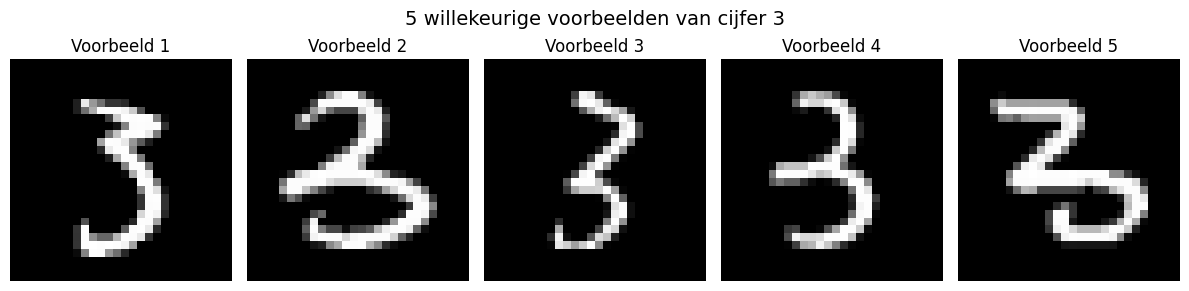

In [2]:
# Kies 5 willekeurige 3-en
np.random.seed(42)
indices = np.where(y_train == 3)[0]
gekozen = np.random.choice(indices, 5, replace=False)

# Toon de afbeeldingen
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, idx in enumerate(gekozen):
    axes[i].imshow(X_train[idx], cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f'Voorbeeld {i+1}')
plt.suptitle('5 willekeurige voorbeelden van cijfer 3', fontsize=14)
plt.tight_layout()
plt.show()

### Observaties - Wat valt op?
- Verschillende schrijfstijlen
- Dikte lijnen varieert
- Vorm: scherp vs rond
- Grootte verschilt

## 3. Welke cijfers lijken visueel sterk op elkaar?

Vergelijking 4 vs 9:


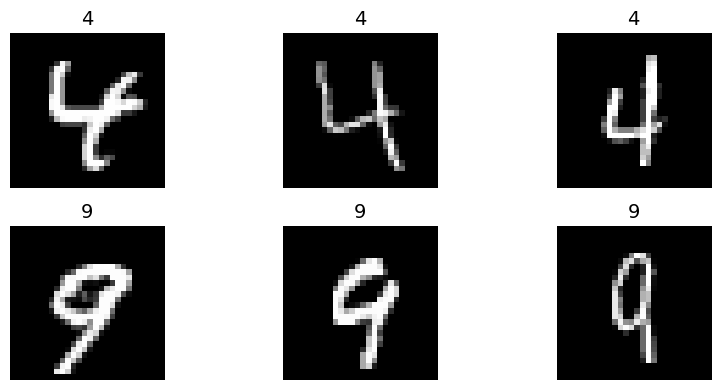


Vergelijking 1 vs 7:


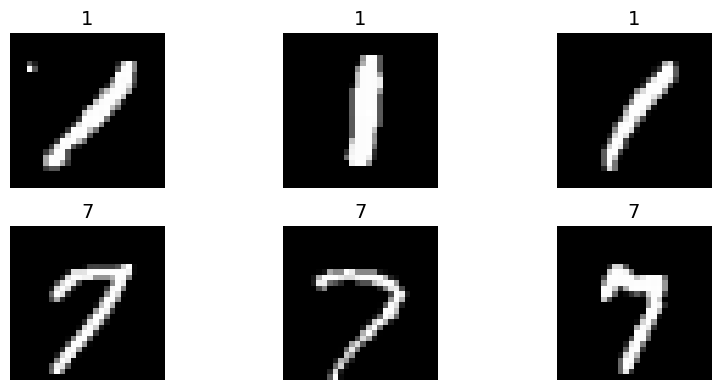

In [3]:
def vergelijk(digita, digitb, n=3):
    idx_a = np.random.choice(np.where(y_train == digita)[0], n, replace=False)
    idx_b = np.random.choice(np.where(y_train == digitb)[0], n, replace=False)
    
    fig, axes = plt.subplots(2, n, figsize=(9, 4))
    for i in range(n):
        axes[0,i].imshow(X_train[idx_a[i]], cmap='gray')
        axes[0,i].set_title(f'{digita}', fontsize=14)
        axes[0,i].axis('off')
        axes[1,i].imshow(X_train[idx_b[i]], cmap='gray')
        axes[1,i].set_title(f'{digitb}', fontsize=14)
        axes[1,i].axis('off')
    plt.tight_layout()
    plt.show()

print("Vergelijking 4 vs 9:")
vergelijk(4, 9)

print("\nVergelijking 1 vs 7:")
vergelijk(1, 7)

### Observaties - Gelijkaardige cijfers
- 4 en 9
- 1 en 7
- 3 en 8
- 5 en 6

## 4. Zijn sommige cijfers "slordiger" geschreven dan andere?

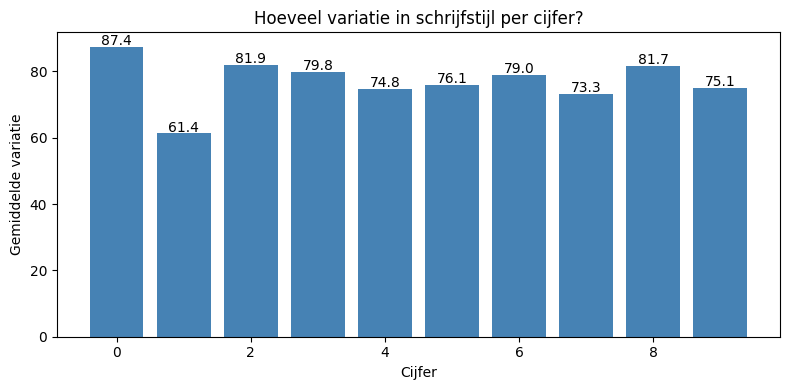

Meest variabel (slordigst): cijfer 0
Minst variabel (netst): cijfer 1


In [4]:
# Bereken variatie per cijfer
variatie = []
for cijfer in range(10):
    subset = X_train[y_train == cijfer]
    gem_std = subset.std(axis=(1,2)).mean()
    variatie.append(gem_std)

# Toon als grafiek
plt.figure(figsize=(8,4))
plt.bar(range(10), variatie, color='steelblue')
plt.xlabel('Cijfer')
plt.ylabel('Gemiddelde variatie')
plt.title('Hoeveel variatie in schrijfstijl per cijfer?')
for i, v in enumerate(variatie):
    plt.text(i, v+0.5, f'{v:.1f}', ha='center')
plt.tight_layout()
plt.show()

print(f"Meest variabel (slordigst): cijfer {np.argmax(variatie)}")
print(f"Minst variabel (netst): cijfer {np.argmin(variatie)}")

### Observaties - Slordigheid
- Cijfer 0 heeft de meeste variatie
- Cijfer 1 is het meest consistent
- Cijfer 8 varieert veel
- Slordige cijfers zijn moeilijker te herkennen

## 5. Conclusie - Waarom is classificatie lastig?

1. Mensen schrijven hetzelfde cijfer verschillend
2. Sommige cijfers lijken op elkaar (4/9, 1/7, 3/8)
3. Slordig handschrift vervaagt grenzen
4. Lage resolutie (28x28) maakt details onduidelijk